# 14. LaMa LPIPS Perceptual Metrics

This notebook computes LPIPS perceptual-distance metrics for the LaMa restoration baseline on the controlled 50-painting subset.

LPIPS is computed between:

- clean reference and damaged input,
- clean reference and LaMa restored output.

Lower LPIPS means higher perceptual similarity.

The evaluation uses the same LPIPS framework previously applied to OpenCV Telea, enabling later direct model comparison.

## Evaluation design

LPIPS is computed over image-like spatial regions:

- `full_image`,
- `content_region`,
- `mask_bbox_crop`.

Sparse masked pixels are not evaluated directly with LPIPS, because LPIPS expects spatial image patches rather than unordered pixel sets.

For the controlled 50-painting subset, the expected output size is:

- 250 full-image rows,
- 250 content-region rows,
- 200 mask-bounding-box crop rows,

for a total of 700 LPIPS metric rows.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import yaml

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

src_path = PROJECT_ROOT / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from restoration_eval.metrics_lpips import (
    DEFAULT_CROP_RESIZE,
    DEFAULT_LPIPS_NET,
    DEFAULT_MASK_BBOX_MARGIN,
    compute_lpips_metrics_for_restorations,
    get_device,
    load_lpips_model,
    rank_lpips_cases,
    summarize_lpips_metrics,
    validate_lpips_metrics,
)

print("Project root:", PROJECT_ROOT)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
config_path = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if not config_path.exists():
    raise FileNotFoundError(f"Config file not found: {config_path}")

with open(config_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config["paths"]

processed_metadata_dir = PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
figures_dir = PROJECT_ROOT / paths_cfg["figures_dir"]

metrics_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

lama_metadata_path = processed_metadata_dir / "metadata_restored_lama.csv"
processed_clean_metadata_path = processed_metadata_dir / "metadata_processed_clean.csv"

lpips_metrics_path = metrics_dir / "lpips_metrics_lama_50.csv"
summary_by_mask_type_path = metrics_dir / "lpips_summary_by_mask_type_lama_50.csv"
summary_by_category_path = metrics_dir / "lpips_summary_by_category_lama_50.csv"
summary_by_region_path = metrics_dir / "lpips_summary_by_region_lama_50.csv"
summary_by_region_mask_type_path = metrics_dir / "lpips_summary_by_region_mask_type_lama_50.csv"
summary_by_category_region_path = metrics_dir / "lpips_summary_by_category_region_lama_50.csv"

strongest_lpips_cases_path = metrics_dir / "lama_strongest_lpips_cases_50.csv"
weakest_lpips_cases_path = metrics_dir / "lama_weakest_lpips_cases_50.csv"

lpips_diagnostic_figures_dir = figures_dir / "lpips_diagnostics" / "lama"
lpips_diagnostic_figures_dir.mkdir(parents=True, exist_ok=True)

model_name = "lama"
target_size = 768
lpips_net = DEFAULT_LPIPS_NET
crop_resize = DEFAULT_CROP_RESIZE
mask_bbox_margin = DEFAULT_MASK_BBOX_MARGIN

print("LaMa metadata:", lama_metadata_path)
print("Processed clean metadata:", processed_clean_metadata_path)
print("LPIPS metrics output:", lpips_metrics_path)
print("LPIPS net:", lpips_net)
print("Crop resize:", crop_resize)
print("Mask bbox margin:", mask_bbox_margin)

LaMa metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_lama.csv
Processed clean metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
LPIPS metrics output: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_lama_50.csv
LPIPS net: alex
Crop resize: 256
Mask bbox margin: 32


In [3]:
required_input_paths = [
    lama_metadata_path,
    processed_clean_metadata_path,
]

for input_path in required_input_paths:
    if not input_path.exists():
        raise FileNotFoundError(f"Missing required input: {input_path}")

lama_restored_df = pd.read_csv(lama_metadata_path)
processed_clean_df = pd.read_csv(processed_clean_metadata_path)

print("Raw LaMa metadata shape:", lama_restored_df.shape)
print("Processed clean metadata shape:", processed_clean_df.shape)

metadata_lookup_columns = [
    "painting_id",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_lookup_columns = [
    column for column in metadata_lookup_columns
    if column not in processed_clean_df.columns
]

if missing_lookup_columns:
    raise ValueError(
        f"Processed clean metadata missing required lookup columns: {missing_lookup_columns}"
    )

metadata_lookup_df = (
    processed_clean_df[metadata_lookup_columns]
    .drop_duplicates(subset=["painting_id"])
    .copy()
)

if metadata_lookup_df["category"].isna().any():
    raise ValueError("Processed clean metadata contains missing category labels.")

lama_cases_df = lama_restored_df.copy()

columns_to_replace = [
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

lama_cases_df = lama_cases_df.drop(
    columns=[column for column in columns_to_replace if column in lama_cases_df.columns],
    errors="ignore",
)

lama_cases_df = lama_cases_df.merge(
    metadata_lookup_df,
    on="painting_id",
    how="left",
)

required_after_merge = [
    "category",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_after_merge = lama_cases_df[required_after_merge].isna().sum()

print("Missing values after metadata enrichment:")
display(missing_after_merge)

if missing_after_merge.sum() != 0:
    display(
        lama_cases_df[
            lama_cases_df[required_after_merge].isna().any(axis=1)
        ].head(20)
    )
    raise ValueError("LaMa metadata enrichment failed.")

print("Enriched LaMa metadata shape:", lama_cases_df.shape)

print("\nCategory counts:")
display(lama_cases_df["category"].value_counts().sort_index())

print("\nMask type counts:")
display(lama_cases_df["mask_type"].value_counts().sort_index())

display(
    lama_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "model_name",
            "status",
            "content_x_min",
            "content_y_min",
            "content_x_max",
            "content_y_max",
        ]
    ].head()
)

Raw LaMa metadata shape: (250, 32)
Processed clean metadata shape: (50, 43)
Missing values after metadata enrichment:


category         0
content_x_min    0
content_y_min    0
content_x_max    0
content_y_max    0
dtype: int64

Enriched LaMa metadata shape: (250, 38)

Category counts:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64


Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64

,case_id,painting_id,category,title,mask_type,model_name,status,content_x_min,content_y_min,content_x_max,content_y_max
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,lama,ok,52,0,715,768
1,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,lama,ok,52,0,715,768
2,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,lama,ok,52,0,715,768
3,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,lama,ok,52,0,715,768
4,p001_zero_control,p001,portrait_figure,Juan de Pareja,zero_control,lama,ok,52,0,715,768


In [4]:
required_case_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_id",
    "mask_type",
    "model_name",
    "clean_path",
    "mask_path",
    "damaged_path",
    "restored_path",
    "status",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_case_columns = [
    column for column in required_case_columns
    if column not in lama_cases_df.columns
]

if missing_case_columns:
    raise ValueError(f"LaMa cases metadata missing columns: {missing_case_columns}")

if len(lama_cases_df) != 250:
    raise ValueError(f"Expected 250 LaMa cases, found {len(lama_cases_df)}.")

if lama_cases_df["case_id"].duplicated().any():
    duplicate_case_ids = lama_cases_df.loc[
        lama_cases_df["case_id"].duplicated(),
        "case_id",
    ].tolist()
    raise ValueError(f"Duplicate case IDs found: {duplicate_case_ids[:10]}")

if (lama_cases_df["status"] != "ok").any():
    display(lama_cases_df[lama_cases_df["status"] != "ok"])
    raise ValueError("LaMa cases contain non-ok rows.")

if set(lama_cases_df["model_name"].unique()) != {model_name}:
    raise ValueError(
        f"Unexpected model names: {lama_cases_df['model_name'].unique()}"
    )

expected_mask_counts = {
    "loss_large": 50,
    "loss_small": 50,
    "mixed_damage": 50,
    "scratch_thin": 50,
    "zero_control": 50,
}

actual_mask_counts = lama_cases_df["mask_type"].value_counts().to_dict()

print("Expected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 50,
    "landscape_natural": 50,
    "architecture_structured": 50,
    "abstraction_surrealism": 50,
    "high_texture_brushwork": 50,
}

actual_category_counts = lama_cases_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

lama_cases_abs_df = lama_cases_df.copy()

for path_column in ["clean_path", "mask_path", "damaged_path", "restored_path"]:
    lama_cases_abs_df[path_column] = lama_cases_abs_df[path_column].apply(
        lambda value: str(PROJECT_ROOT / value) if not Path(value).is_absolute() else value
    )

missing_files = []

for path_column in ["clean_path", "mask_path", "damaged_path", "restored_path"]:
    missing_column_files = [
        path for path in lama_cases_abs_df[path_column]
        if not Path(path).exists()
    ]

    if missing_column_files:
        missing_files.extend(missing_column_files[:10])

if missing_files:
    raise FileNotFoundError(f"Missing image/mask files: {missing_files[:10]}")

print("\nLaMa LPIPS metadata gates passed.")

Expected mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}
Actual mask counts: {'loss_large': 50, 'loss_small': 50, 'mixed_damage': 50, 'scratch_thin': 50, 'zero_control': 50}

Expected category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}
Actual category counts: {'portrait_figure': 50, 'landscape_natural': 50, 'architecture_structured': 50, 'abstraction_surrealism': 50, 'high_texture_brushwork': 50}

LaMa LPIPS metadata gates passed.


In [5]:
device = get_device(prefer_cuda=True)

print("Selected device:", device)

lpips_model = load_lpips_model(
    net=lpips_net,
    device=device,
)

print("LPIPS model loaded.")

Selected device: cuda
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(mode

LPIPS model loaded.


In [6]:
smoke_case_ids = []

# One non-zero damage case.
smoke_case_ids.append(
    lama_cases_abs_df[
        lama_cases_abs_df["mask_type"] != "zero_control"
    ]
    .sort_values("case_id")
    ["case_id"]
    .iloc[0]
)

# One zero-control sanity case.
smoke_case_ids.append(
    lama_cases_abs_df[
        lama_cases_abs_df["mask_type"] == "zero_control"
    ]
    .sort_values("case_id")
    ["case_id"]
    .iloc[0]
)

smoke_cases_df = (
    lama_cases_abs_df[
        lama_cases_abs_df["case_id"].isin(smoke_case_ids)
    ]
    .copy()
    .set_index("case_id")
    .loc[smoke_case_ids]
    .reset_index()
)

print("Smoke test cases:")
display(
    smoke_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "mask_type",
            "model_name",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ]
)

smoke_lpips_df = compute_lpips_metrics_for_restorations(
    restoration_metadata=smoke_cases_df,
    lpips_model=lpips_model,
    device=device,
    lpips_net=lpips_net,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    crop_resize=crop_resize,
    progress_every=1,
)

print("Smoke LPIPS shape:", smoke_lpips_df.shape)

display(smoke_lpips_df)

Smoke test cases:


,case_id,painting_id,category,mask_type,model_name,clean_path,damaged_path,restored_path,mask_path
0,p001_loss_large,p001,portrait_figure,loss_large,lama,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_zero_control,p001,portrait_figure,zero_control,lama,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


Starting LPIPS computation for 2 restoration cases...
Expected LPIPS metric rows: 5
Device: cuda
LPIPS net: alex
Processed 1/2 restoration cases...
Processed 2/2 restoration cases...
LPIPS computation finished.
Smoke LPIPS shape: (5, 24)


,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,damaged_area_percentage_content,damaged_area_percentage_full,damaged_lpips,restored_lpips,lpips_improvement,lpips_net,crop_resize,device,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,full_image,589824,0,...,13.2058,11.4003,0.264050,0.045897,0.218153,alex,256,cuda,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,content_region,509184,52,...,13.2058,11.4003,0.288218,0.049712,0.238506,alex,256,cuda,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,mask_bbox_crop,178929,197,...,13.2058,11.4003,0.592107,0.147469,0.444638,alex,256,cuda,ok,
3,p001_zero_control,p001,portrait_figure,Juan de Pareja,p001_zero_control,zero_control,lama,full_image,589824,0,...,0.0000,0.0000,0.000000,0.000000,0.000000,alex,256,cuda,ok,
4,p001_zero_control,p001,portrait_figure,Juan de Pareja,p001_zero_control,zero_control,lama,content_region,509184,52,...,0.0000,0.0000,0.000000,0.000000,0.000000,alex,256,cuda,ok,


In [7]:
smoke_validation_df = validate_lpips_metrics(
    smoke_lpips_df,
    expected_rows=5,
)

print("Smoke LPIPS validation:")
display(smoke_validation_df)

if not smoke_validation_df["passed"].all():
    display(smoke_lpips_df)
    raise ValueError("Smoke LPIPS validation failed.")

if (smoke_lpips_df["status"] != "ok").any():
    display(smoke_lpips_df[smoke_lpips_df["status"] != "ok"])
    raise ValueError("Smoke LPIPS contains non-ok rows.")

print("Smoke LPIPS test passed.")

Smoke LPIPS validation:


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 5, found 5."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 2, 'content_region': 2, 'mask_b..."


Smoke LPIPS test passed.


In [8]:
lpips_metrics_df = compute_lpips_metrics_for_restorations(
    restoration_metadata=lama_cases_abs_df,
    lpips_model=lpips_model,
    device=device,
    lpips_net=lpips_net,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    crop_resize=crop_resize,
    progress_every=10,
)

print("LaMa LPIPS metrics shape:", lpips_metrics_df.shape)

display(lpips_metrics_df.head())

print("\nEvaluation region counts:")
display(lpips_metrics_df["evaluation_region"].value_counts())

print("\nMask type counts:")
display(lpips_metrics_df["mask_type"].value_counts().sort_index())

print("\nCategory counts:")
display(lpips_metrics_df["category"].value_counts().sort_index())

print("\nStatus counts:")
display(lpips_metrics_df["status"].value_counts(dropna=False))

if (lpips_metrics_df["status"] != "ok").any():
    display(lpips_metrics_df[lpips_metrics_df["status"] != "ok"])
    raise ValueError("Some LaMa LPIPS rows failed.")

print("Full LaMa LPIPS computation completed.")

Starting LPIPS computation for 250 restoration cases...
Expected LPIPS metric rows: 700
Device: cuda
LPIPS net: alex
Processed 1/250 restoration cases...
Processed 10/250 restoration cases...
Processed 20/250 restoration cases...
Processed 30/250 restoration cases...
Processed 40/250 restoration cases...
Processed 50/250 restoration cases...
Processed 60/250 restoration cases...
Processed 70/250 restoration cases...
Processed 80/250 restoration cases...
Processed 90/250 restoration cases...
Processed 100/250 restoration cases...
Processed 110/250 restoration cases...
Processed 120/250 restoration cases...
Processed 130/250 restoration cases...
Processed 140/250 restoration cases...
Processed 150/250 restoration cases...
Processed 160/250 restoration cases...
Processed 170/250 restoration cases...
Processed 180/250 restoration cases...
Processed 190/250 restoration cases...
Processed 200/250 restoration cases...
Processed 210/250 restoration cases...
Processed 220/250 restoration cases.

,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,damaged_area_percentage_content,damaged_area_percentage_full,damaged_lpips,restored_lpips,lpips_improvement,lpips_net,crop_resize,device,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,full_image,589824,0,...,13.2058,11.4003,0.264050,0.045897,0.218153,alex,256,cuda,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,content_region,509184,52,...,13.2058,11.4003,0.288218,0.049712,0.238506,alex,256,cuda,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,lama,mask_bbox_crop,178929,197,...,13.2058,11.4003,0.592107,0.147469,0.444638,alex,256,cuda,ok,
3,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,lama,full_image,589824,0,...,4.7523,4.1026,0.335288,0.002392,0.332896,alex,256,cuda,ok,
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,lama,content_region,509184,52,...,4.7523,4.1026,0.318926,0.002862,0.316065,alex,256,cuda,ok,



Evaluation region counts:


evaluation_region
full_image        250
content_region    250
mask_bbox_crop    200
Name: count, dtype: int64


Mask type counts:


...


Category counts:


category
abstraction_surrealism     140
architecture_structured    140
high_texture_brushwork     140
landscape_natural          140
portrait_figure            140
Name: count, dtype: int64


Status counts:


status
ok    700
Name: count, dtype: int64

Full LaMa LPIPS computation completed.


In [9]:
lpips_validation_df = validate_lpips_metrics(
    lpips_metrics_df,
    expected_rows=700,
)

print("LaMa LPIPS validation:")
display(lpips_validation_df)

if not lpips_validation_df["passed"].all():
    raise ValueError("LaMa LPIPS validation failed.")

if (lpips_metrics_df["status"] != "ok").any():
    display(lpips_metrics_df[lpips_metrics_df["status"] != "ok"])
    raise ValueError("LaMa LPIPS output contains non-ok rows.")

expected_region_counts = {
    "full_image": 250,
    "content_region": 250,
    "mask_bbox_crop": 200,
}

actual_region_counts = lpips_metrics_df["evaluation_region"].value_counts().to_dict()

print("Expected region counts:", expected_region_counts)
print("Actual region counts:", actual_region_counts)

for region, expected_count in expected_region_counts.items():
    actual_count = actual_region_counts.get(region, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Region {region!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 140,
    "landscape_natural": 140,
    "architecture_structured": 140,
    "abstraction_surrealism": 140,
    "high_texture_brushwork": 140,
}

actual_category_counts = lpips_metrics_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

print("LaMa LPIPS validation passed.")

LaMa LPIPS validation:


,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 700, found 700."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 250, 'content_region': 250, 'ma..."


Expected region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}
Actual region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}

Expected category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}
Actual category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}
LaMa LPIPS validation passed.


In [10]:
lpips_metrics_df.to_csv(lpips_metrics_path, index=False)

print("Saved LaMa LPIPS metrics:")
print(lpips_metrics_path)

saved_lpips_df = pd.read_csv(lpips_metrics_path)

print("Saved shape:", saved_lpips_df.shape)

if len(saved_lpips_df) != 700:
    raise ValueError(
        f"Expected 700 saved LPIPS rows, found {len(saved_lpips_df)}."
    )

if (saved_lpips_df["status"] != "ok").any():
    display(saved_lpips_df[saved_lpips_df["status"] != "ok"])
    raise ValueError("Saved LaMa LPIPS metrics contain non-ok rows.")

print("Full LaMa LPIPS metrics saved successfully.")

Saved LaMa LPIPS metrics:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_metrics_lama_50.csv
Saved shape: (700, 24)
Full LaMa LPIPS metrics saved successfully.


In [11]:
summary_by_mask_type_df = summarize_lpips_metrics(
    lpips_metrics_df,
    group_columns=["mask_type"],
)

summary_by_category_df = summarize_lpips_metrics(
    lpips_metrics_df,
    group_columns=["category"],
)

summary_by_region_df = summarize_lpips_metrics(
    lpips_metrics_df,
    group_columns=["evaluation_region"],
)

summary_by_region_mask_type_df = summarize_lpips_metrics(
    lpips_metrics_df,
    group_columns=["evaluation_region", "mask_type"],
)

summary_by_category_region_df = summarize_lpips_metrics(
    lpips_metrics_df,
    group_columns=["category", "evaluation_region"],
)

print("Summary by mask type:")
display(summary_by_mask_type_df)

print("\nSummary by category:")
display(summary_by_category_df)

print("\nSummary by evaluation region:")
display(summary_by_region_df)

print("\nSummary by evaluation region and mask type:")
display(summary_by_region_mask_type_df)

print("\nSummary by category and evaluation region:")
display(summary_by_category_region_df)

Summary by mask type:


,mask_type,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,loss_large,150,50,0.28864,0.09568,0.19297,0.22400,0.06758,0.16213,1.0,406007.07333
1,loss_small,150,50,0.17794,0.00831,0.16963,0.16297,0.00747,0.15413,1.0,489403.76000
2,mixed_damage,150,50,0.32552,0.02521,0.30031,0.32162,0.02388,0.30188,1.0,538795.30667
3,scratch_thin,150,50,0.26742,0.00207,0.26535,0.26032,0.00168,0.25864,1.0,538267.44667
4,zero_control,100,50,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,522240.00000



Summary by category:


,category,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,abstraction_surrealism,140,50,0.15709,0.02828,0.12881,0.16623,0.00725,0.13008,0.85714,524982.70000
1,architecture_structured,140,50,0.24875,0.02989,0.21886,0.23516,0.00977,0.21500,0.85714,482446.84286
2,high_texture_brushwork,140,50,0.24115,0.02934,0.21181,0.24249,0.00949,0.23148,0.85714,496638.98571
3,landscape_natural,140,50,0.22840,0.02766,0.20074,0.21585,0.01011,0.18682,0.85714,480574.62143
4,portrait_figure,140,50,0.25981,0.02547,0.23434,0.25284,0.00609,0.23976,0.85714,501749.97857



Summary by evaluation region:


,evaluation_region,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,content_region,250,250,0.20812,0.02044,0.18767,0.20350,0.00767,0.17931,0.8,454656.00
1,full_image,250,250,0.17717,0.01575,0.16142,0.17143,0.00560,0.14604,0.8,589824.00
2,mask_bbox_crop,200,200,0.31303,0.05321,0.25982,0.29492,0.01529,0.25834,1.0,434875.19



Summary by evaluation region and mask type:


,evaluation_region,mask_type,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,content_region,loss_large,50,50,0.20968,0.06147,0.14821,0.19131,0.05950,0.13912,1.0,454656.00
1,content_region,loss_small,50,50,0.18592,0.00875,0.17717,0.17568,0.00828,0.16397,1.0,454656.00
2,content_region,mixed_damage,50,50,0.35524,0.02974,0.32550,0.34546,0.02837,0.32636,1.0,454656.00
3,content_region,scratch_thin,50,50,0.28975,0.00226,0.28749,0.29345,0.00173,0.28756,1.0,454656.00
4,content_region,zero_control,50,50,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,454656.00
5,full_image,loss_large,50,50,0.17097,0.04823,0.12273,0.16219,0.04542,0.11445,1.0,589824.00
6,full_image,loss_small,50,50,0.15516,0.00606,0.14910,0.14588,0.00606,0.14038,1.0,589824.00
7,full_image,mixed_damage,50,50,0.30743,0.02253,0.28491,0.30914,0.02211,0.28176,1.0,589824.00
8,full_image,scratch_thin,50,50,0.25229,0.00193,0.25036,0.25050,0.00161,0.24866,1.0,589824.00
9,full_image,zero_control,50,50,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,589824.00



Summary by category and evaluation region:


,category,evaluation_region,rows,cases,mean_damaged_lpips,mean_restored_lpips,mean_lpips_improvement,median_damaged_lpips,median_restored_lpips,median_lpips_improvement,improvement_rate,mean_region_pixel_count
0,abstraction_surrealism,content_region,50,50,0.13888,0.01997,0.11891,0.15564,0.00575,0.11072,0.8,506419.200
1,abstraction_surrealism,full_image,50,50,0.12536,0.01716,0.10819,0.12675,0.00443,0.09969,0.8,589824.000
2,abstraction_surrealism,mask_bbox_crop,40,40,0.21952,0.05256,0.16696,0.19249,0.01222,0.16204,1.0,467135.450
3,architecture_structured,content_region,50,50,0.22577,0.02130,0.20447,0.23081,0.00783,0.18847,0.8,437760.000
4,architecture_structured,full_image,50,50,0.19410,0.01576,0.17833,0.20054,0.00543,0.16750,0.8,589824.000
5,architecture_structured,mask_bbox_crop,40,40,0.34580,0.05830,0.28751,0.32303,0.01890,0.29626,1.0,404083.950
6,high_texture_brushwork,content_region,50,50,0.22183,0.02154,0.20029,0.23608,0.00986,0.20871,0.8,458803.200
7,high_texture_brushwork,full_image,50,50,0.18810,0.01666,0.17144,0.20397,0.00754,0.16627,0.8,589824.000
8,high_texture_brushwork,mask_bbox_crop,40,40,0.33162,0.05494,0.27668,0.31414,0.01523,0.26687,1.0,427452.450
9,landscape_natural,content_region,50,50,0.21906,0.02183,0.19723,0.22344,0.00949,0.18517,0.8,413030.400


In [12]:
summary_by_mask_type_df.to_csv(summary_by_mask_type_path, index=False)
summary_by_category_df.to_csv(summary_by_category_path, index=False)
summary_by_region_df.to_csv(summary_by_region_path, index=False)
summary_by_region_mask_type_df.to_csv(summary_by_region_mask_type_path, index=False)
summary_by_category_region_df.to_csv(summary_by_category_region_path, index=False)

saved_summary_paths = [
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    summary_by_category_region_path,
]

print("Saved LPIPS summary files:")

for path in saved_summary_paths:
    if not path.exists():
        raise FileNotFoundError(f"Missing saved summary file: {path}")
    print(path)

print("All LaMa LPIPS summary files saved.")

Saved LPIPS summary files:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_summary_by_mask_type_lama_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_summary_by_category_lama_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_summary_by_region_lama_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_summary_by_region_mask_type_lama_50.csv
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lpips_summary_by_category_region_lama_50.csv
All LaMa LPIPS summary files saved.


In [13]:
strongest_lpips_cases_df, weakest_lpips_cases_df = rank_lpips_cases(
    lpips_metrics_df,
    evaluation_region="mask_bbox_crop",
    top_n=20,
)

print("Strongest LaMa LPIPS improvement cases:")
display(
    strongest_lpips_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "evaluation_region",
            "damaged_lpips",
            "restored_lpips",
            "lpips_improvement",
        ]
    ]
)

print("\nWeakest LaMa LPIPS improvement cases:")
display(
    weakest_lpips_cases_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "evaluation_region",
            "damaged_lpips",
            "restored_lpips",
            "lpips_improvement",
        ]
    ]
)

if len(strongest_lpips_cases_df) != 20:
    raise ValueError(
        f"Expected 20 strongest LPIPS cases, found {len(strongest_lpips_cases_df)}."
    )

if len(weakest_lpips_cases_df) != 20:
    raise ValueError(
        f"Expected 20 weakest LPIPS cases, found {len(weakest_lpips_cases_df)}."
    )

print("LaMa LPIPS case ranking completed.")

Strongest LaMa LPIPS improvement cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,damaged_lpips,restored_lpips,lpips_improvement
0,p011_loss_large,p011,landscape_natural,View of Haarlem and the Haarlemmer Meer,loss_large,mask_bbox_crop,0.659316,0.125666,0.533650
1,p010_mixed_damage,p010,portrait_figure,Joan of Arc,mixed_damage,mask_bbox_crop,0.496727,0.015907,0.480820
2,p006_scratch_thin,p006,portrait_figure,Boy with a Sword,scratch_thin,mask_bbox_crop,0.466244,0.000910,0.465335
3,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,mask_bbox_crop,0.589203,0.140967,0.448236
4,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,mask_bbox_crop,0.592107,0.147469,0.444638
5,p006_loss_large,p006,portrait_figure,Boy with a Sword,loss_large,mask_bbox_crop,0.598758,0.158868,0.439890
6,p027_mixed_damage,p027,architecture_structured,Italian Landscape with the Ponte Lucano over t...,mixed_damage,mask_bbox_crop,0.468302,0.032694,0.435608
7,p026_mixed_damage,p026,architecture_structured,View of a Village along a River,mixed_damage,mask_bbox_crop,0.452454,0.024192,0.428262
8,p042_loss_large,p042,high_texture_brushwork,View of Beirut,loss_large,mask_bbox_crop,0.447033,0.019812,0.427221
9,p006_mixed_damage,p006,portrait_figure,Boy with a Sword,mixed_damage,mask_bbox_crop,0.438148,0.014129,0.424019



Weakest LaMa LPIPS improvement cases:


,case_id,painting_id,category,title,mask_type,evaluation_region,damaged_lpips,restored_lpips,lpips_improvement
0,p036_loss_small,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",loss_small,mask_bbox_crop,0.060125,0.000232,0.059893
1,p035_loss_small,p035,abstraction_surrealism,The Bewitched Mill,loss_small,mask_bbox_crop,0.067258,0.003505,0.063753
2,p035_scratch_thin,p035,abstraction_surrealism,The Bewitched Mill,scratch_thin,mask_bbox_crop,0.072722,0.000456,0.072266
3,p034_loss_small,p034,abstraction_surrealism,Painting with Green Center,loss_small,mask_bbox_crop,0.094964,0.015089,0.079875
4,p031_loss_small,p031,abstraction_surrealism,Improvisation No. 30 (Cannons),loss_small,mask_bbox_crop,0.092560,0.009212,0.083347
5,p017_scratch_thin,p017,landscape_natural,Picturesque Landscape,scratch_thin,mask_bbox_crop,0.093232,0.002525,0.090707
6,p016_scratch_thin,p016,landscape_natural,Wooded Landscape with a House beside a River,scratch_thin,mask_bbox_crop,0.101436,0.004991,0.096444
7,p033_loss_small,p033,abstraction_surrealism,Movement,loss_small,mask_bbox_crop,0.112698,0.012163,0.100535
8,p036_scratch_thin,p036,abstraction_surrealism,"Lozenge Composition with Yellow, Black, Blue, ...",scratch_thin,mask_bbox_crop,0.105427,0.000803,0.104624
9,p040_loss_small,p040,abstraction_surrealism,Houses at Murnau,loss_small,mask_bbox_crop,0.115828,0.008036,0.107791


LaMa LPIPS case ranking completed.


In [14]:
strongest_lpips_cases_df.to_csv(strongest_lpips_cases_path, index=False)
weakest_lpips_cases_df.to_csv(weakest_lpips_cases_path, index=False)

print("Saved strongest LPIPS cases:")
print(strongest_lpips_cases_path)

print("\nSaved weakest LPIPS cases:")
print(weakest_lpips_cases_path)

for path in [strongest_lpips_cases_path, weakest_lpips_cases_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing saved ranking file: {path}")

print("LaMa LPIPS ranking files saved.")

Saved strongest LPIPS cases:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lama_strongest_lpips_cases_50.csv

Saved weakest LPIPS cases:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\lama_weakest_lpips_cases_50.csv
LaMa LPIPS ranking files saved.


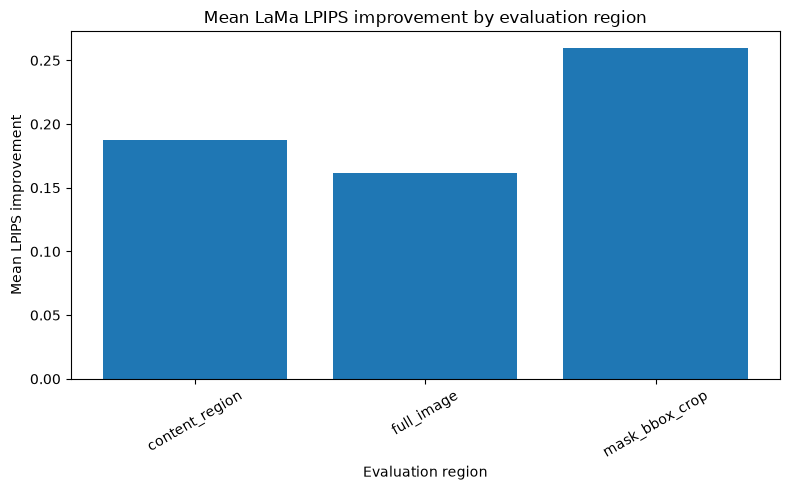

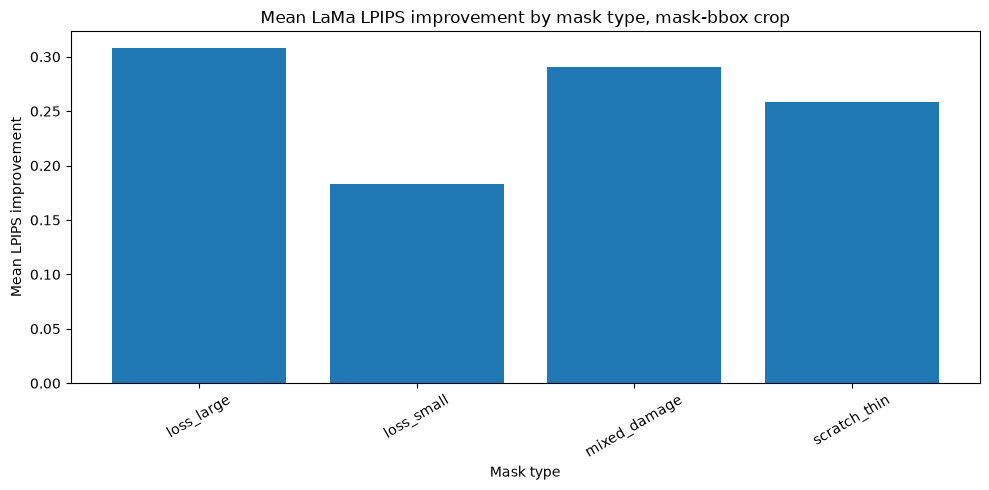

In [15]:
plot_region_df = summary_by_region_df.copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    plot_region_df["evaluation_region"],
    plot_region_df["mean_lpips_improvement"],
)

ax.set_title("Mean LaMa LPIPS improvement by evaluation region")
ax.set_xlabel("Evaluation region")
ax.set_ylabel("Mean LPIPS improvement")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


plot_mask_df = summary_by_region_mask_type_df[
    summary_by_region_mask_type_df["evaluation_region"] == "mask_bbox_crop"
].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    plot_mask_df["mask_type"],
    plot_mask_df["mean_lpips_improvement"],
)

ax.set_title("Mean LaMa LPIPS improvement by mask type, mask-bbox crop")
ax.set_xlabel("Mask type")
ax.set_ylabel("Mean LPIPS improvement")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [17]:
expected_output_files = [
    lpips_metrics_path,
    summary_by_mask_type_path,
    summary_by_category_path,
    summary_by_region_path,
    summary_by_region_mask_type_path,
    summary_by_category_region_path,
    strongest_lpips_cases_path,
    weakest_lpips_cases_path,
]

for output_file in expected_output_files:
    if not output_file.exists():
        raise FileNotFoundError(f"Missing expected output file: {output_file}")

saved_lpips_df = pd.read_csv(lpips_metrics_path)

if len(saved_lpips_df) != 700:
    raise ValueError(
        f"Expected 700 saved LPIPS rows, found {len(saved_lpips_df)}."
    )

if (saved_lpips_df["status"] != "ok").any():
    display(saved_lpips_df[saved_lpips_df["status"] != "ok"])
    raise ValueError("Saved LPIPS metrics contain non-ok rows.")

expected_region_counts = {
    "full_image": 250,
    "content_region": 250,
    "mask_bbox_crop": 200,
}

actual_region_counts = saved_lpips_df["evaluation_region"].value_counts().to_dict()

print("Expected region counts:", expected_region_counts)
print("Actual region counts:", actual_region_counts)

for region, expected_count in expected_region_counts.items():
    actual_count = actual_region_counts.get(region, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Region {region!r}: expected {expected_count}, found {actual_count}."
        )

expected_mask_counts = {
    "loss_large": 150,
    "loss_small": 150,
    "mixed_damage": 150,
    "scratch_thin": 150,
    "zero_control": 100,
}

actual_mask_counts = saved_lpips_df["mask_type"].value_counts().to_dict()

print("\nExpected mask counts:", expected_mask_counts)
print("Actual mask counts:", actual_mask_counts)

for mask_type, expected_count in expected_mask_counts.items():
    actual_count = actual_mask_counts.get(mask_type, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Mask type {mask_type!r}: expected {expected_count}, found {actual_count}."
        )

expected_category_counts = {
    "portrait_figure": 140,
    "landscape_natural": 140,
    "architecture_structured": 140,
    "abstraction_surrealism": 140,
    "high_texture_brushwork": 140,
}

actual_category_counts = saved_lpips_df["category"].value_counts().to_dict()

print("\nExpected category counts:", expected_category_counts)
print("Actual category counts:", actual_category_counts)

for category, expected_count in expected_category_counts.items():
    actual_count = actual_category_counts.get(category, 0)
    if actual_count != expected_count:
        raise ValueError(
            f"Category {category!r}: expected {expected_count}, found {actual_count}."
        )

if saved_lpips_df["category"].isna().any():
    raise ValueError("Saved LPIPS metrics contain missing category labels.")

if saved_lpips_df["lpips_improvement"].isna().any():
    raise ValueError("Saved LPIPS metrics contain missing LPIPS improvement values.")

saved_strongest_df = pd.read_csv(strongest_lpips_cases_path)
saved_weakest_df = pd.read_csv(weakest_lpips_cases_path)

if len(saved_strongest_df) != 20:
    raise ValueError(
        f"Expected 20 strongest LPIPS cases, found {len(saved_strongest_df)}."
    )

if len(saved_weakest_df) != 20:
    raise ValueError(
        f"Expected 20 weakest LPIPS cases, found {len(saved_weakest_df)}."
    )

print("\nSaved LPIPS rows:", len(saved_lpips_df))
print("Strongest LPIPS cases:", len(saved_strongest_df))
print("Weakest LPIPS cases:", len(saved_weakest_df))
print("Final LaMa LPIPS output gates passed.")

Expected region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}
Actual region counts: {'full_image': 250, 'content_region': 250, 'mask_bbox_crop': 200}

Expected mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}
Actual mask counts: {'loss_large': 150, 'loss_small': 150, 'mixed_damage': 150, 'scratch_thin': 150, 'zero_control': 100}

Expected category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}
Actual category counts: {'portrait_figure': 140, 'landscape_natural': 140, 'architecture_structured': 140, 'abstraction_surrealism': 140, 'high_texture_brushwork': 140}

Saved LPIPS rows: 700
Strongest LPIPS cases: 20
Weakest LPIPS cases: 20
Final LaMa LPIPS output gates passed.


## Notebook 14 summary

This notebook computed LPIPS perceptual-distance metrics for the LaMa restoration baseline on the controlled 50-painting subset.

LPIPS was computed between:

- clean reference and damaged input,
- clean reference and LaMa restored output.

The evaluated regions were:

- `full_image`,
- `content_region`,
- `mask_bbox_crop`.

Sparse masked-region LPIPS was intentionally not computed because LPIPS expects image-like spatial regions rather than unordered damaged pixels.

Main outputs:

- `outputs/metrics/lpips_metrics_lama_50.csv`
- `outputs/metrics/lpips_summary_by_mask_type_lama_50.csv`
- `outputs/metrics/lpips_summary_by_category_lama_50.csv`
- `outputs/metrics/lpips_summary_by_region_lama_50.csv`
- `outputs/metrics/lpips_summary_by_region_mask_type_lama_50.csv`
- `outputs/metrics/lpips_summary_by_category_region_lama_50.csv`
- `outputs/metrics/lama_strongest_lpips_cases_50.csv`
- `outputs/metrics/lama_weakest_lpips_cases_50.csv`

The final LPIPS output contains 700 rows:

- 250 full-image rows,
- 250 content-region rows,
- 200 mask-bounding-box crop rows.

These results add a perceptual similarity layer to the LaMa evaluation and prepare the model for later comparison with OpenCV Telea and future generative inpainting baselines.